[Index](Index.ipynb) - [Prev](Random_number.ipynb) - [Next](Index.ipynb)

## Measurements <a id='measurements'></a>
So far, all of our measurements are done in the Z-basis, but there is nothing intrinsically special about this basis.
We can "create" our own measurements in any basis.

In the exercise on the Hadamard gate you saw that you could create an X-gate by 'sandwiching' a Z-gate between two H-gates:
$X=HZH$. Starting in the Z-basis, the H-gate switches our qubit to the X-basis, the Z-gate peforms a NOT in the X-basis, and the final H-gate returns our qubit to the Z-basis.

Following the same logic, we can create a measurement in the X-basis by sandwiching our Z-measurement between two H-gates, and other measurement bases can be created using diffenerent 'sandwiches'.

total counts for |0> are: 1024


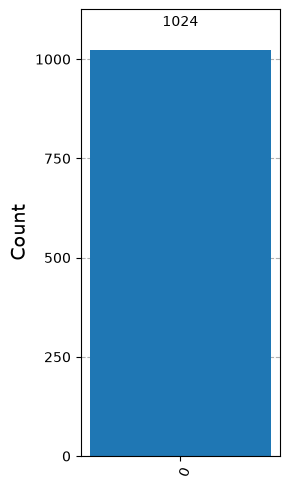

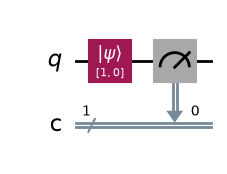

In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer.primitives import SamplerV2
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, inset_axes

def x_measurement(qc,qubit,cbit):
    """Measure 'qubit' in the X-basis, and store the result in 'cbit'"""
    qc.h(qubit)
    qc.measure(qubit, cbit)
    qc.h(qubit)
    return qc

def y_measurement(qc,qubit,cbit):
    """Measure 'qubit' in the Y-basis, and store the result in 'cbit'"""
    qc.s(qubit)
    qc.h(qubit)
    qc.measure(qubit, cbit)
    qc.h(qubit)
    qc.sdg(qubit)
    return qc

#define circuit
q = QuantumRegister(1, 'q')
c = ClassicalRegister(1, 'c')
circuit = QuantumCircuit(q,c)

# Define initial_state alpha=1, beta=0 --> state |0>
initial_state = [1,0]   
circuit.initialize(initial_state, 0) # Apply initialisation operation to the 0th qubit

# ---- Add extra gates to execute on qubit here----

# Add a measurement to the circuit

# Z measurement
circuit.measure(q, c)

# X measurment
#x_measurement(circuit, 0, 0)

# Y measurment
#y_measurement(circuit, 0, 0)

# define simulator
sampler = SamplerV2()
# execute the circuit with this simulator
job = sampler.run([circuit]).result()
counts = job[0].data.c.get_counts()

for r in range(len(counts)):
    print(f'total counts for |{str(r)}> are: {counts[str(r)]}')
    
# plot histogram
display(plot_histogram(counts,figsize=(3,5)))

# draw circuit
display(circuit.draw(output='mpl'))


> Q6 What happens when you measure in different basis? Do you get what you expected?

Measuring in different bases allows us to also witness Heisenberg’s famous "uncertainty principle" in action. Having certainty of measuring a state in the Z-basis removes all certainty of measuring a specific state in the X-basis, and vice versa. A common misconception is that the uncertainty is due to the limits in our equipment, here we can see the uncertainty is actually part of the nature of the qubit.

For example, if we put our qubit in the state $|0\rangle$, our measurement in the Z-basis is certain to give the outcome $|0\rangle$, but our measurement in the X-basis is completely random! ($|+\rangle$ or $|-\rangle$). Similarly, if we put our qubit in the state $|-\rangle$, our measurement in the X-basis is certain to be $|-\rangle$ but now any measurement in the Z-basis will be completely random.